# 01 - CSV Data & Data Quality

I started with the supplied CSV and checked the data before changing anything.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file = "../01_Data/raw/household_power_consumption.csv"
df = pd.read_csv(file, na_values="?")

In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 1048575
Columns: 9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1044506 non-null  float64
 3   Global_reactive_power  1044506 non-null  float64
 4   Voltage                1044506 non-null  float64
 5   Global_intensity       1044506 non-null  float64
 6   Sub_metering_1         1044506 non-null  float64
 7   Sub_metering_2         1044506 non-null  float64
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(7), object(2)
memory usage: 72.0+ MB


## Missing values

First I checked where the missing values are.

In [6]:
missing = df.isna().sum()
print(missing)

Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3           4069
dtype: int64


In [7]:
bad_rows = df.isna().any(axis=1).sum()
print("Rows with missing values:", bad_rows)

Rows with missing values: 4069


In [8]:
print("Missing rows (%):", round(bad_rows / len(df) * 100, 2))

Missing rows (%): 0.39


## Duplicate check

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Simple numeric check

In [10]:
num_cols = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]

In [11]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [12]:
print(df[num_cols].describe().round(2))

       Global_active_power  ...  Sub_metering_3
count           1044506.00  ...      1044506.00
mean                  1.11  ...            5.93
std                   1.13  ...            8.21
min                   0.08  ...            0.00
25%                   0.29  ...            0.00
50%                   0.55  ...            0.00
75%                   1.54  ...           17.00
max                  10.67  ...           31.00

[8 rows x 7 columns]


## Missing values visual

This makes the small amount of missing data easy to see.

In [13]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

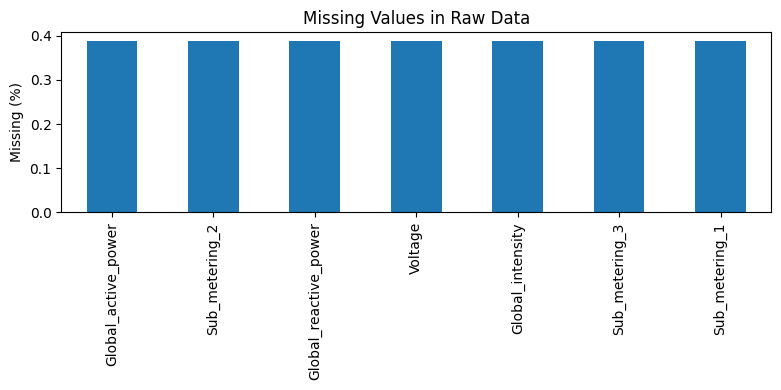

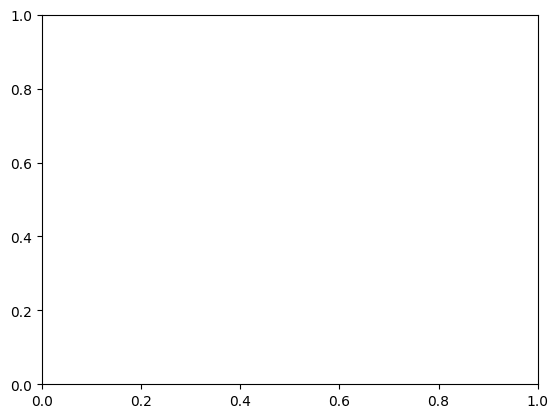

In [14]:
plt.figure(figsize=(8,4))
missing_pct.plot(kind="bar")
plt.ylabel("Missing (%)")
plt.title("Missing Values in Raw Data")
plt.tight_layout()
plt.show()
plt.savefig("../04_Visuals/eda/06_missing_values.png", dpi=150)
plt.show()


### What I checked

The file is minute-level household electricity data. I found a small missing-data issue, so I keep the raw file unchanged and do the cleaning in the next notebook.